# Pipeline B (v3): Speech Assessment

**Goal:** extract interpretable speech delivery features from user audio for English speaking practice.

**v3 additions:** Parselmouth features (jitter, shimmer, HNR) + syllable-based speaking rate estimation + SpeechOcean762 feature extraction for classifier training.

**Outputs:** extended feature set ready for trained classifier

## Setup & Imports

In [1]:
import os
from pathlib import Path

import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import parselmouth
from parselmouth.praat import call
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d
from collections import Counter

C:\Users\User\miniconda3\envs\spoofdet\lib\site-packages\librosa\util\files.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## Configuration

In [2]:
# ===== Config ====-=
TARGET_SR = 16000

# Silence detection settings
FRAME_LENGTH = 2048
HOP_LENGTH = 512
TOP_DB = 30   # lower =stricter silence detection

#Pitch range for human speech (a typical safe oen)
FMIN = 75
FMAX = 400

#minimum pause duration to count as a real pause
MIN_PAUSE_SEC = 0.25

## Audio Loading & Standardization

In [3]:
def load_audio(path, target_sr=TARGET_SR):
    """
    Load audio as mono waveform and resample to target_sr.
    Returns:
        y  -> waveform (numpy array)
        sr -> sample rate
    """
    y, sr = librosa.load(path, sr=target_sr, mono=True)
    return y, sr

## Silence / Speech Detection

In [4]:
def detect_non_silent_intervals(y, sr, top_db=TOP_DB, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH):
    """
    Returns non-silent intervals in samples.
    Each row is [start_sample, end_sample].
    """
    intervals = librosa.effects.split(
        y,
        top_db=top_db,
        frame_length=frame_length,
        hop_length=hop_length
    )
    return intervals

## Timing/ Fluency Feature Extraction

In [5]:
def extract_timing_features(y, sr, intervals):
    '''
    #Extract timing/fluency features from detected speech intervals.
    '''
    total_duration_sec = len(y) / sr

    if len(intervals) == 0:
        return {
            "total_duration_sec": total_duration_sec,
            "speech_duration_sec": 0.0,
            "pause_count": 0,
            "avg_pause_duration_sec": 0.0,
            "hesitation_ratio": 1.0
        }

    # speech duration
    speech_samples = sum(end - start for start, end in intervals)
    speech_duration_sec = speech_samples / sr

    # pauses = gaps between speech intervals
    pause_durations = []
    for i in range(1, len(intervals)):
        prev_end = intervals[i - 1][1]
        curr_start = intervals[i][0]
        pause_sec = (curr_start - prev_end) / sr
        if pause_sec > MIN_PAUSE_SEC:
            pause_durations.append(pause_sec)

    pause_count = len(pause_durations)
    avg_pause_duration_sec = float(np.mean(pause_durations)) if pause_durations else 0.0

    silence_duration_sec = max(total_duration_sec - speech_duration_sec, 0.0)
    hesitation_ratio = silence_duration_sec / total_duration_sec if total_duration_sec > 0 else 0.0

    return {
        "total_duration_sec": float(total_duration_sec),
        "speech_duration_sec": float(speech_duration_sec),
        "pause_count": int(pause_count),
        "avg_pause_duration_sec": float(avg_pause_duration_sec),
        "hesitation_ratio": float(hesitation_ratio)
    }

## Pitch and Energy feature extraction

In [6]:
def extract_pitch_energy_features(y, sr, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH):
    """
    #Extract pitch and energy statistics.
    """

    # =---- Energy (RMS) -----
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    energy_mean = float(np.mean(rms))
    energy_std = float(np.std(rms))

    # ----- Pitch (YIN) -----
    f0 = librosa.yin(y, fmin=FMIN, fmax=FMAX, sr=sr, frame_length=frame_length, hop_length=hop_length)

    # Remove invalid or zero values
    f0_valid = f0[np.isfinite(f0)]
    f0_valid = f0_valid[f0_valid > 0]

    if len(f0_valid) == 0:
        pitch_mean_hz = 0.0
        pitch_std_hz = 0.0
        pitch_range_hz = 0.0
    else:
        pitch_mean_hz = float(np.mean(f0_valid))
        pitch_std_hz = float(np.std(f0_valid))
        pitch_range_hz = float(np.percentile(f0_valid, 95) - np.percentile(f0_valid, 5))

    return {
        "pitch_mean_hz": pitch_mean_hz,
        "pitch_std_hz": pitch_std_hz,
        "pitch_range_hz": pitch_range_hz,
        "energy_mean": energy_mean,
        "energy_std": energy_std
    }

## Parselmouth Feature Extraction (Jitter, Shimmer, HNR)

In [7]:
def extract_parselmouth_features(y, sr):
    #extract voice quality features using Parselmouth (Praat)

    sound = parselmouth.Sound(y, sampling_frequency=sr)

    try:
        #75-500Hz = typical range for human voices
        point_process = call(sound, "To PointProcess (periodic, cc)", 75, 500)

        #Jitter
        #Normal speec = <1%. High values = rough or tense voice.
        jitter = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)

        #Shimmmer 
        #Normal speech = <3%. High values = breathy or unstable voice
        shimmer = call([sound, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)

        #HNR
        #Higher = clearer voice (normal speech: 20+ dB). Lower = breathy, hoarse, or background noise.
        harmonicity = call(sound, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr = call(harmonicity, "Get mean", 0, 0)

    except Exception as e:
        print(f" [Parselmouth warning]: {e}")
        jitter, shimmer, hnr = 0.0, 0.0, 0.0

    return {
        "jitter": float(jitter) if jitter is not None else 0.0,
        "shimmer": float(shimmer) if jitter is not None else 0.0,
        "hnr": float(hnr) if hnr is not None else 0.0,
    }

## Speaking Rate Estimation (Syllable-Based)

In [8]:
def estimate_speaking_rate(y, sr, intervals):
    #English speech averages ~220-260 syllables/min in presentations. source:
    
    #Get RMS energy envelope 
    hop = 512
    rms = librosa.feature.rms(y=y, hop_length=hop)[0]

    from scipy.ndimage import uniform_filter1d
    rms_smooth = uniform_filter1d(rms.astype(float), size=5)

    peaks, _ = find_peaks(
        rms_smooth, 
        distance=4, 
        height=rms_smooth.mean() *0.5
    )

    speech_peaks = 0
    for peak in peaks:
        peak_sample = peak * hop
        for start, end in intervals:
            if start <= peak_sample <= end:
                speech_peaks += 1
                break

    
    speech_samples = sum(e - s for s, e in intervals) if len(intervals) > 0 else 0
    speech_duration_min = (speech_samples / sr) / 60.0
    syllable_rate = speech_peaks / speech_duration_min if speech_duration_min > 0 else 0

    return {
        "syllable_rate_per_min": round(float(syllable_rate), 2),
        "estimated_syllable_count": int(speech_peaks)
    }

    

## Full Pipeline B Feature Extraction function

In [9]:
def analyze_audio_features(path):
    """
    Full Pipeline B v3 feature extraction.
    Extracts all features from a single audio file:
    - timing/fluency (pause count, hesitation ration, etc)
    - pitch and energy statistics
    - voice quality via Parselmouth (jitter, shimmer, HNR)
    - Speaking rate estimation (syllable-based)
    """
    y, sr = load_audio(path)
    intervals = detect_non_silent_intervals(y, sr)
    
    timing_feats = extract_timing_features(y, sr, intervals)
    pitch_energy_feats = extract_pitch_energy_features(y, sr)
    parselmouth_feats = extract_parselmouth_features(y, sr)
    speaking_rate_feats = estimate_speaking_rate(y, sr, intervals)
    
    features = {}
    features.update(timing_feats)
    features.update(pitch_energy_feats)
    features.update(parselmouth_feats)
    features.update(speaking_rate_feats)
    
    return features

## Test on one Audio File

In [10]:
test_audio_path = r"C:\Users\User\Desktop\PB testing audio\General1_Test2_M-L.wav"
features = analyze_audio_features(test_audio_path)
features

{'total_duration_sec': 38.59,
 'speech_duration_sec': 26.976,
 'pause_count': 11,
 'avg_pause_duration_sec': 0.9163636363636365,
 'hesitation_ratio': 0.3009587976159628,
 'pitch_mean_hz': 178.57518283700213,
 'pitch_std_hz': 70.29067558113456,
 'pitch_range_hz': 192.2003210356943,
 'energy_mean': 0.02684762515127659,
 'energy_std': 0.023973507806658745,
 'jitter': 0.015424286270175457,
 'shimmer': 0.08113182712402257,
 'hnr': 15.243516218054411,
 'syllable_rate_per_min': 153.47,
 'estimated_syllable_count': 69}

### Clearer Output

In [11]:
for k, v in features.items():
    print(f"{k}: {v}")

total_duration_sec: 38.59
speech_duration_sec: 26.976
pause_count: 11
avg_pause_duration_sec: 0.9163636363636365
hesitation_ratio: 0.3009587976159628
pitch_mean_hz: 178.57518283700213
pitch_std_hz: 70.29067558113456
pitch_range_hz: 192.2003210356943
energy_mean: 0.02684762515127659
energy_std: 0.023973507806658745
jitter: 0.015424286270175457
shimmer: 0.08113182712402257
hnr: 15.243516218054411
syllable_rate_per_min: 153.47
estimated_syllable_count: 69


## Rule-Based Scoring and Feedback

In [12]:
# ==== F;uency scoring ====
def score_fluency(features):
    score = 0
    feedback = []

    total_dur = features["total_duration_sec"]
    pause_count = features["pause_count"]
    avg_pause = features["avg_pause_duration_sec"]
    hesitation_ratio = features["hesitation_ratio"]

    # Normalise pause count to per-minute so short and long clips are comparable
    duration_minutes = total_dur / 60.0
    pauses_per_minute = pause_count / duration_minutes if duration_minutes > 0 else 0

    # --- Pause count per minute ---
    # Too few pauses (< 2/min) is also bad — sounds rushed or robotic
    if pauses_per_minute < 2:
        score += 1
        feedback.append("Your delivery has very few pauses, which can sound rushed or robotic.")
    elif pauses_per_minute <= 8:
        score += 3
        feedback.append("Your use of pauses is natural and well-paced.")
    elif pauses_per_minute <= 14:
        score += 2
        feedback.append("Your pauses are noticeable but still within a moderate range.")
    else:
        score += 1
        feedback.append("You pause quite frequently, which may reduce fluency.")

    # --- Average pause duration ---
    if avg_pause == 0.0:
        # No pauses at all — penalise
        score += 1
        feedback.append("No clear pauses detected — natural pausing improves delivery.")
    elif avg_pause <= 0.4:
        score += 3
        feedback.append("Your pauses are mostly short and natural.")
    elif avg_pause <= 0.8:
        score += 2
        feedback.append("Some pauses are slightly long.")
    else:
        score += 1
        feedback.append("Your pauses are often long, which may interrupt flow.")

    # --- Hesitation ratio ---
    if hesitation_ratio <= 0.20:
        score += 3
        feedback.append("Your speech flow is smooth and well-timed.")
    elif hesitation_ratio <= 0.32:
        score += 2
        feedback.append("There is a moderate amount of silence in your delivery.")
    else:
        score += 1
        feedback.append("A large portion of your delivery contains silence or hesitation.")

    avg_score = score / 3.0
    return avg_score, feedback

In [13]:
# ===== Prosody scoring ===
def score_prosody(features):
    score = 0
    feedback = []

    pitch_std = features["pitch_std_hz"]
    pitch_range = features["pitch_range_hz"]
    energy_std = features["energy_std"]

    # --- Pitch variability (raised thresholds — yin produces noisy estimates) ---
    if pitch_std >= 60:
        score += 3
        feedback.append("Your pitch variation makes your delivery sound expressive and engaging.")
    elif pitch_std >= 35:
        score += 2
        feedback.append("Your pitch variation is moderate — slightly more variation would improve expressiveness.")
    else:
        score += 1
        feedback.append("Your speech sounds quite monotone. Try varying your pitch to emphasise key points.")

    # --- Pitch range (now using percentile-based range, not raw min/max) ---
    if pitch_range >= 80:
        score += 3
        feedback.append("Your pitch range supports an engaging speaking style.")
    elif pitch_range >= 40:
        score += 2
        feedback.append("Your pitch range is acceptable but could be more expressive.")
    else:
        score += 1
        feedback.append("Your pitch range is quite narrow — try to vary your intonation more.")

    # --- Energy variability (fixed boundaries) ---
    if energy_std >= 0.03:
        score += 3
        feedback.append("Your loudness variation is good and helps maintain listener engagement.")
    elif energy_std >= 0.01:
        score += 2
        feedback.append("Your loudness variation is moderate.")
    else:
        score += 1
        feedback.append("Your voice is quite flat in volume. Try to vary your loudness to emphasise key points.")

    avg_score = score / 3.0
    return avg_score, feedback

In [14]:
#==== overall level=====

def score_to_level(score):
    """
    #Convert average score to Low / Medium / High.
    """
    if score >= 2.67:
        return "High"
    elif score >= 2.0:
        return "Medium"
    else:
        return "Low"

In [15]:
# ===== full scoring Function ======

def assess_delivery(features):
    """
    Combine fluency and prosody scoring into one assessment.
    Returns scores, level, and feedback.
    """

    fluency_score, fluency_feedback = score_fluency(features)
    prosody_score, prosody_feedback = score_prosody(features)

    overall_score = (fluency_score + prosody_score) / 2.0
    overall_level = score_to_level(overall_score)

    feedback = fluency_feedback + prosody_feedback

    # Add one short summary line
    if overall_level == "High":
        feedback.insert(0, "Your delivery is generally strong and clear.")
    elif overall_level == "Medium":
        feedback.insert(0, "Your delivery is fairly good but has some areas for improvement.")
    else:
        feedback.insert(0, "Your delivery needs improvement in fluency and/or expressiveness.")

    return {
        "fluency_score": round(fluency_score, 2),
        "prosody_score": round(prosody_score, 2),
        "overall_score": round(overall_score, 2),
        "overall_level": overall_level,
        "feedback": feedback
    }

## Test Rule-Based Assessment

In [16]:
assessment = assess_delivery(features)
assessment

{'fluency_score': 1.33,
 'prosody_score': 2.67,
 'overall_score': 2.0,
 'overall_level': 'Medium',
 'feedback': ['Your delivery is fairly good but has some areas for improvement.',
  'You pause quite frequently, which may reduce fluency.',
  'Your pauses are often long, which may interrupt flow.',
  'There is a moderate amount of silence in your delivery.',
  'Your pitch variation makes your delivery sound expressive and engaging.',
  'Your pitch range supports an engaging speaking style.',
  'Your loudness variation is moderate.']}

In [17]:
#clearer output
print(f"fluency_score: {assessment['fluency_score']}")
print(f"prosody_score: {assessment['prosody_score']}")
print(f"overall_score: {assessment['overall_score']}")
print(f"overall_level: {assessment['overall_level']}")

print("\nfeedback:")
for item in assessment["feedback"]:
    print(f"- {item}")

fluency_score: 1.33
prosody_score: 2.67
overall_score: 2.0
overall_level: Medium

feedback:
- Your delivery is fairly good but has some areas for improvement.
- You pause quite frequently, which may reduce fluency.
- Your pauses are often long, which may interrupt flow.
- There is a moderate amount of silence in your delivery.
- Your pitch variation makes your delivery sound expressive and engaging.
- Your pitch range supports an engaging speaking style.
- Your loudness variation is moderate.


## Combine Feature Extraction and Assessment Output

In [18]:
def run_pipeline_b(path):
    """
    Full Pipeline B v1:
    1. Extract raw delivery features
    2. Assess delivery using rule-based scoring
    3. Return one combined result
    """
    features = analyze_audio_features(path)
    assessment = assess_delivery(features)

    result = {
        "features": features,
        "assessment": assessment
    }

    return result

## Test Full Pipeline B Output

In [19]:
pipeline_b_result = run_pipeline_b(test_audio_path)
pipeline_b_result

{'features': {'total_duration_sec': 38.59,
  'speech_duration_sec': 26.976,
  'pause_count': 11,
  'avg_pause_duration_sec': 0.9163636363636365,
  'hesitation_ratio': 0.3009587976159628,
  'pitch_mean_hz': 178.57518283700213,
  'pitch_std_hz': 70.29067558113456,
  'pitch_range_hz': 192.2003210356943,
  'energy_mean': 0.02684762515127659,
  'energy_std': 0.023973507806658745,
  'jitter': 0.015424286270175457,
  'shimmer': 0.08113182712402257,
  'hnr': 15.243516218054411,
  'syllable_rate_per_min': 153.47,
  'estimated_syllable_count': 69},
 'assessment': {'fluency_score': 1.33,
  'prosody_score': 2.67,
  'overall_score': 2.0,
  'overall_level': 'Medium',
  'feedback': ['Your delivery is fairly good but has some areas for improvement.',
   'You pause quite frequently, which may reduce fluency.',
   'Your pauses are often long, which may interrupt flow.',
   'There is a moderate amount of silence in your delivery.',
   'Your pitch variation makes your delivery sound expressive and engagin

In [20]:
#Clearer output

print("=== FEATURES ===")
for k, v in pipeline_b_result["features"].items():
    print(f"{k}: {v}")

print("\n=== ASSESSMENT ===")
print(f"fluency_score: {pipeline_b_result['assessment']['fluency_score']}")
print(f"prosody_score: {pipeline_b_result['assessment']['prosody_score']}")
print(f"overall_score: {pipeline_b_result['assessment']['overall_score']}")
print(f"overall_level: {pipeline_b_result['assessment']['overall_level']}")

print("\n=== FEEDBACK ===")
for item in pipeline_b_result["assessment"]["feedback"]:
    print(f"- {item}")

=== FEATURES ===
total_duration_sec: 38.59
speech_duration_sec: 26.976
pause_count: 11
avg_pause_duration_sec: 0.9163636363636365
hesitation_ratio: 0.3009587976159628
pitch_mean_hz: 178.57518283700213
pitch_std_hz: 70.29067558113456
pitch_range_hz: 192.2003210356943
energy_mean: 0.02684762515127659
energy_std: 0.023973507806658745
jitter: 0.015424286270175457
shimmer: 0.08113182712402257
hnr: 15.243516218054411
syllable_rate_per_min: 153.47
estimated_syllable_count: 69

=== ASSESSMENT ===
fluency_score: 1.33
prosody_score: 2.67
overall_score: 2.0
overall_level: Medium

=== FEEDBACK ===
- Your delivery is fairly good but has some areas for improvement.
- You pause quite frequently, which may reduce fluency.
- Your pauses are often long, which may interrupt flow.
- There is a moderate amount of silence in your delivery.
- Your pitch variation makes your delivery sound expressive and engaging.
- Your pitch range supports an engaging speaking style.
- Your loudness variation is moderate.


## SpeechOcean762 - Dataset Loading

In [21]:
import json

DATASET_ROOT = Path(r"C:\FYP\Datasets\speechocean762")

def load_speechocean_split(split="train"):
    scp_path = DATASET_ROOT / split / "wav.scp"
    utt2path = {}

    with open(scp_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            utt_id = parts[0]
            rel_path = parts[1]
            full_path = DATASET_ROOT / rel_path
            utt2path[utt_id] = full_path

    return utt2path

def load_scores(min_utterances_per_speaker=1):
    scores_path = DATASET_ROOT / "resource" / "scores.json"

    with open(scores_path, "r") as f:
        scores_raw = json.load(f)

    scores = {}
    for utt_id, data in scores_raw.items():
        scores[utt_id] = {
            "fluency": float(data["fluency"]),
            "prosodic": float(data["prosodic"]),
            "accuracy": float(data["accuracy"]),
        }

    return scores


#Test

utt2path_train = load_speechocean_split("train")
utt2path_test = load_speechocean_split("test")
scores = load_scores()

print(f"Train utterances: {len(utt2path_train)}")
print(f"Test utterances: {len(utt2path_test)}")
print(f"Total scores: {len(scores)}")
print(f"\nExample utterance path: {list(utt2path_train.items())[0]}")
print(f"Example score entry: {list(scores.items())[0]}")

Train utterances: 2500
Test utterances: 2500
Total scores: 5000

Example utterance path: ('000010011', WindowsPath('C:/FYP/Datasets/speechocean762/WAVE/SPEAKER0001/000010011.WAV'))
Example score entry: ('000010011', {'fluency': 9.0, 'prosodic': 9.0, 'accuracy': 8.0})


## Label Mapping - Scores to low / Medium / High

In [22]:
def score_to_label(fluency_score, prosodic_score):
    #map speechocean762 human scores (0-10) to three-class labels
    """
    Thresholds adjusted based on actual score distribution analysis.
    The dataset skews high (median=8.0) so shifted boundaries up accordingly:
    - High:   >= 8.5  (top ~33% of speakers)
    - Medium: >= 7.0  (middle ~46%)
    - Low:    <  7.0  (bottom ~21%)
    """

    combined = (fluency_score + prosodic_score) / 2.0
    
    if combined >= 8.5:
        return "High"
    elif combined >= 7.0:
        return "Medium"
    else: 
        return "Low"


# Recheck distribution with new thresholds
all_labels = []
for utt_id, s in scores.items():
    label = score_to_label(s["fluency"], s["prosodic"])
    all_labels.append(label)

dist = Counter(all_labels)
print("Label distribution with adjusted thresholds:")
for label, count in sorted(dist.items()):
    pct = count / len(all_labels) * 100
    print(f"  {label}: {count} ({pct:.1f}%)")


Label distribution with adjusted thresholds:
  High: 1747 (34.9%)
  Low: 1069 (21.4%)
  Medium: 2184 (43.7%)


## Score Distribution Analysis

Combined score statistics:
  Min:    0.0
  Max:    10.0
  Mean:   7.62
  Median: 8.00
  Std:    1.45

  Threshold 5.0: 238 below (4.8%), 4762 above (95.2%)
  Threshold 6.0: 526 below (10.5%), 4474 above (89.5%)
  Threshold 6.5: 776 below (15.5%), 4224 above (84.5%)
  Threshold 7.0: 1069 below (21.4%), 3931 above (78.6%)
  Threshold 7.5: 1615 below (32.3%), 3385 above (67.7%)
  Threshold 8.0: 2116 below (42.3%), 2884 above (57.7%)


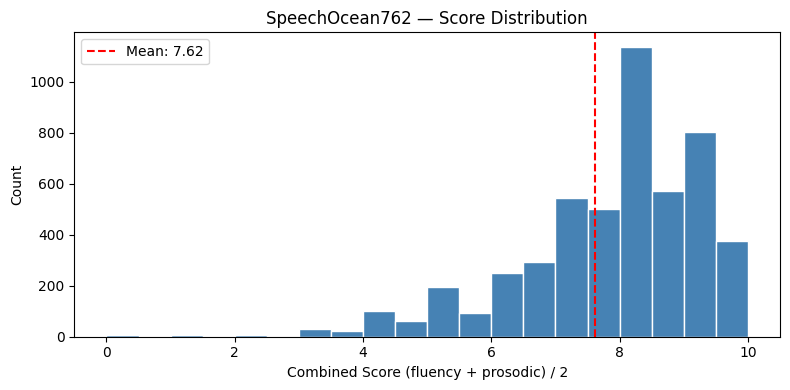

In [23]:
import matplotlib.pyplot as plt

#Look at the actual distribution of combined scores
combined_scores = []
for utt_id, s in scores.items():
    combined = (s["fluency"] + s["prosodic"]) / 2.0
    combined_scores.append(combined)

combined_scores = np.array(combined_scores)

print("Combined score statistics:")
print(f"  Min:    {combined_scores.min():.1f}")
print(f"  Max:    {combined_scores.max():.1f}")
print(f"  Mean:   {combined_scores.mean():.2f}")
print(f"  Median: {np.median(combined_scores):.2f}")
print(f"  Std:    {combined_scores.std():.2f}")
print()

# Show counts at each threshold to help pick better boundaries
for threshold in [5.0, 6.0, 6.5, 7.0, 7.5, 8.0]:
    below = (combined_scores < threshold).sum()
    above = (combined_scores >= threshold).sum()
    print(f"  Threshold {threshold}: {below} below ({below/len(combined_scores)*100:.1f}%), {above} above ({above/len(combined_scores)*100:.1f}%)")

#Plot the distribution
plt.figure(figsize=(8, 4))
plt.hist(combined_scores, bins=20, color="steelblue", edgecolor="white")
plt.axvline(combined_scores.mean(), color="red", linestyle="--", label=f"Mean: {combined_scores.mean():.2f}")
plt.xlabel("Combined Score (fluency + prosodic) / 2")
plt.ylabel("Count")
plt.title("SpeechOcean762 — Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Extraction Loop - SpeechOcean762

In [24]:
import time
import csv

OUTPUT_CSV = Path(r"C:\FYP\fyp-speaking-skills-app\PipelineB_SpeechAssessment\speechocean762_features.csv")

def extract_features_safe(audio_path):
    try:
        return analyze_audio_features(str(audio_path))
    except Exception as e:
        return None

all_utterances = {}
all_utterances.update(utt2path_train)
all_utterances.update(utt2path_test)

#Only keep utterances with scores
valid_utterances = {
    utt_id: path
    for utt_id, path in all_utterances.items()
    if utt_id in scores
}

print(f"Total utterances to process: {len(valid_utterances)}")
print("Starting feature extraction... (this will take 20-40 minutes)")
print("Progress will be printed every 100 utterances.\n")

results = []
failed = []
start_time = time.time()

for i, (utt_id, audio_path) in enumerate(valid_utterances.items()):
    features = extract_features_safe(audio_path)

    if features is None:
        failed.append(utt_id)
        continue

    # Get label for this utterance
    s = scores[utt_id]
    label = score_to_label(s["fluency"], s["prosodic"])
    
    # Combine everything into one row
    row = {"utt_id": utt_id, "label": label}
    row.update(features)
    row["fluency_score_raw"] = s["fluency"]
    row["prosodic_score_raw"] = s["prosodic"]
    results.append(row)
    
    # Progress update every 100 files
    if (i + 1) % 100 == 0:
        elapsed = time.time() - start_time
        rate = (i + 1) / elapsed
        remaining = (len(valid_utterances) - i - 1) / rate
        print(f"  [{i+1}/{len(valid_utterances)}] "
              f"Elapsed: {elapsed/60:.1f}min  "
              f"ETA: {remaining/60:.1f}min  "
              f"Failed so far: {len(failed)}")


#Save to CSV
if results:
    fieldnames = list(results[0].keys())
    with open(OUTPUT_CSV, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(results)

elapsed_total = time.time() - start_time
print(f"\nDone! Processed {len(results)} utterances in {elapsed_total/60:.1f} minutes")
print(f"Failed/skipped: {len(failed)}")
print(f"Saved to: {OUTPUT_CSV}")

Total utterances to process: 5000
Starting feature extraction... (this will take 20-40 minutes)
Progress will be printed every 100 utterances.

  [100/5000] Elapsed: 0.1min  ETA: 7.3min  Failed so far: 0
  [200/5000] Elapsed: 0.3min  ETA: 7.7min  Failed so far: 0
  [300/5000] Elapsed: 0.5min  ETA: 7.5min  Failed so far: 0
  [400/5000] Elapsed: 0.6min  ETA: 7.4min  Failed so far: 0
  [500/5000] Elapsed: 0.8min  ETA: 7.1min  Failed so far: 0
  [600/5000] Elapsed: 0.9min  ETA: 7.0min  Failed so far: 0
  [700/5000] Elapsed: 1.1min  ETA: 6.8min  Failed so far: 0
  [800/5000] Elapsed: 1.3min  ETA: 6.7min  Failed so far: 0
  [900/5000] Elapsed: 1.4min  ETA: 6.5min  Failed so far: 0
  [1000/5000] Elapsed: 1.6min  ETA: 6.3min  Failed so far: 0
  [1100/5000] Elapsed: 1.7min  ETA: 6.1min  Failed so far: 0
  [1200/5000] Elapsed: 1.8min  ETA: 5.8min  Failed so far: 0
  [1300/5000] Elapsed: 2.0min  ETA: 5.7min  Failed so far: 0
  [1400/5000] Elapsed: 2.1min  ETA: 5.5min  Failed so far: 0
  [1500/500

## Classifier Training - Random Forest

In [25]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import pickle

# Load the extracted features
df = pd.read_csv(r"C:\FYP\fyp-speaking-skills-app\PipelineB_SpeechAssessment\speechocean762_features.csv")

print(f"Dataset shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")

#Feature columns
FEATURE_COLS = [
    "total_duration_sec", "speech_duration_sec", "pause_count",
    "avg_pause_duration_sec", "hesitation_ratio",
    "pitch_mean_hz", "pitch_std_hz", "pitch_range_hz",
    "energy_mean", "energy_std",
    "jitter", "shimmer", "hnr",
    "syllable_rate_per_min", "estimated_syllable_count"
]

X = df[FEATURE_COLS].values
y = df["label"].values

# Encode labels to numbers (High=0, Low=1, Medium=2 alphabetically)
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")

#Train Random  Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",  # handles class imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


#Evaluate
y_pred = rf.predict(X_test)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("=== Confusion Matrix ===")
print(pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=[f"True {c}" for c in le.classes_],
    columns=[f"Pred {c}" for c in le.classes_]
))

# Feature importance
print("\n=== Feature Importance (top 10) ===")
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
print(importances.sort_values(ascending=False).head(10).round(4))


# Save model and label encoder
MODEL_OUT = r"C:\FYP\fyp-speaking-skills-app\PipelineB_SpeechAssessment\rf_classifier.pkl"
LE_OUT = r"C:\FYP\fyp-speaking-skills-app\PipelineB_SpeechAssessment\label_encoder.pkl"

with open(MODEL_OUT, "wb") as f:
    pickle.dump(rf, f)
with open(LE_OUT, "wb") as f:
    pickle.dump(le, f)

print(f"\nModel saved to: {MODEL_OUT}")
print(f"Label encoder saved to: {LE_OUT}")

Dataset shape: (5000, 19)
Label distribution:
label
Medium    2184
High      1747
Low       1069
Name: count, dtype: int64

Label encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

Train size: 4000, Test size: 1000

=== Classification Report ===
              precision    recall  f1-score   support

        High       0.61      0.60      0.61       349
         Low       0.81      0.68      0.74       214
      Medium       0.59      0.65      0.62       437

    accuracy                           0.64      1000
   macro avg       0.67      0.64      0.65      1000
weighted avg       0.65      0.64      0.64      1000

=== Confusion Matrix ===
             Pred High  Pred Low  Pred Medium
True High          211         3          135
True Low            11       145           58
True Medium        125        30          282

=== Feature Importance (top 10) ===
total_duration_sec     0.1652
speech_duration_sec    0.1085
hnr                    0.0890
shimmer     